1 - import the libraries

2- define the device

3 - load the data

4 - write the class for VAE

5 - Training loop

6 - Visualization

In [62]:
# Libraries
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import torch.optim as optim
from torch.utils.data import DataLoader


In [63]:
# Check for gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [64]:
# Load the data
batch_size = 128
transform = transforms.Compose([transforms.ToTensor()])
train_data = datasets.FashionMNIST(root = './data', download= True ,transform = transform, train = True)
train_loader = DataLoader(batch_size= batch_size, shuffle= True, dataset= train_data)


In [65]:
# VAE CLASS

class VAE(nn.Module):
  def __init__(self,input_dim = 784, hidden_dim = 256 , latent_dim = 128 ):
    super().__init__()
    # encoder layers
    self.fc1 = nn.Linear(input_dim, hidden_dim)
    self.mu = nn.Linear(hidden_dim, latent_dim)
    self.log_var = nn.Linear(hidden_dim, latent_dim)

    # decoder layers
    self.fc2 = nn.Linear(latent_dim, hidden_dim)
    self.fc3 = nn.Linear(hidden_dim, input_dim)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()

  # encoder
  def encoder(self, x):
    h = self.relu(self.fc1(x))
    mu = self.mu(h)
    log_var = self.log_var(h)

    return mu, log_var

  # decoder
  def decoder(self, x):
    h = self.relu(self.fc2(x))
    out = self.sigmoid(self.fc3(h))
    return out

  # reparameterize
  def reparameterize(self, mu, log_var):
    std = torch.exp(0.5*log_var)
    eps = torch.randn_like(std)
    z = mu + eps*std
    return z

  def forward(self, x):
    mu, log_var = self.encoder(x)
    z = self.reparameterize(mu, log_var)
    out = self.decoder(z)
    return out, mu, log_var



In [66]:
# Loss
def loss(x, x_hat, mu, log_var):
  reconstruction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction = 'sum')
  kl_divergence = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
  return reconstruction_loss + kl_divergence




In [67]:
# loading the model
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-3)


In [68]:
epochs = 5

model.train()

for epoch in range(epochs):
  total_loss = 0
  for x,_ in (train_loader):
    x = x.view(-1, 784).to(device)

    optimizer.zero_grad()

    x_hat, mu, log_var = model(x)

    loss_value = loss(x, x_hat, mu, log_var)

    loss_value.backward()

    optimizer.step()

    total_loss = total_loss + loss_value.item()

  avg_loss = total_loss / len(train_loader)

  print(f"epoch[{epoch + 1}/{epochs}], loss {avg_loss:.4f}")


epoch[1/5], loss 38658.4043
epoch[2/5], loss 34787.9188
epoch[3/5], loss 33660.1613
epoch[4/5], loss 32731.2973
epoch[5/5], loss 32191.1766


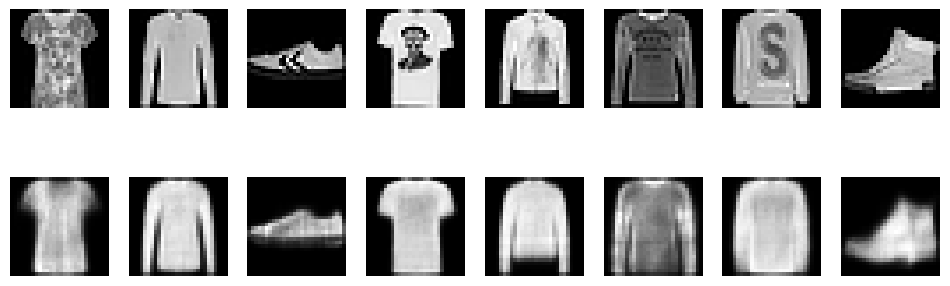

In [69]:
import matplotlib.pyplot as plt
model.eval()

with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, 784).to(device)

    x_hat, _, _ = model(x)

# move to CPU and reshape
x = x.cpu().view(-1, 1, 28, 28)
x_hat = x_hat.cpu().view(-1, 1, 28, 28)

n = 8
plt.figure(figsize=(12, 4))

for i in range(n):
    # original
    plt.subplot(2, n, i + 1)
    plt.imshow(x[i].squeeze(), cmap='gray')
    plt.axis('off')

    # reconstruction
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_hat[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.show()